In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.manifold import TSNE

from skimage import io
from skimage.color import rgb2lab, lab2rgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import MinMaxScaler



In [2]:
def load_images_from_folder(folder_path):
    images = []
    names = []

    for filename in os.listdir(folder_path):
        img = io.imread(os.path.join(folder_path, filename))
        if img is not None:
            images.append(img)
            names.append(filename)

    return images, names

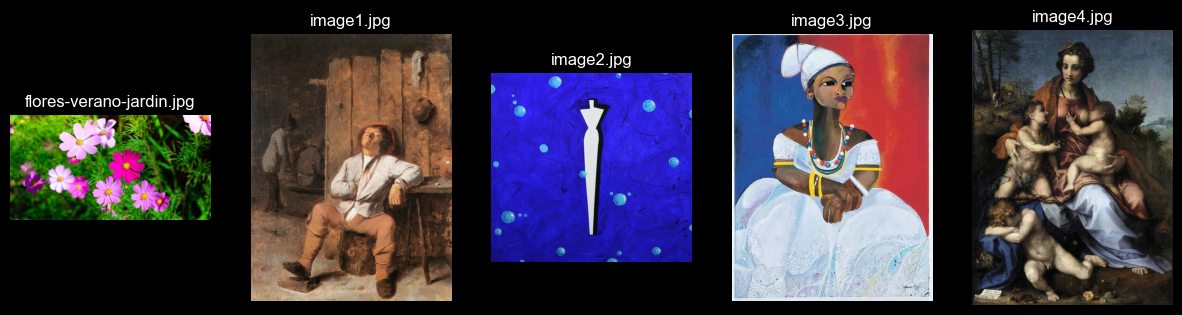

In [3]:
folder_path = "images"
images, names = load_images_from_folder(folder_path)

"Mostrar imágenes seleccionadas"
plt.figure(figsize=(15,5))
for i in range(len(images)):
    plt.subplot(1, len(images), i+1)
    plt.imshow(images[i])
    plt.title(names[i])
    plt.axis("off")
plt.show()

In [4]:
def preprocess_image(image, resize_dim=(400,400)):

    # Redimensionar
    image_resized = cv2.resize(image, resize_dim)

    # Convertir RGB → Lab
    image_lab = rgb2lab(image_resized)

    # Reestructurar a matriz 2D
    pixels = image_lab.reshape((-1, 3))

    # Escalar datos
    scaler = StandardScaler()
    pixels_scaled = scaler.fit_transform(pixels)

    return pixels_scaled, image_resized, scaler

In [5]:
def find_optimal_k(pixels, k_range=(2,10), sample_size=5000):

    # Submuestreo
    if len(pixels) > sample_size:
        idx = np.random.choice(len(pixels), sample_size, replace=False)
        pixels_sample = pixels[idx]
    else:
        pixels_sample = pixels

    best_k = 2
    best_score = -1
    silhouette_scores = []

    for k in range(k_range[0], k_range[1]+1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(pixels_sample)

        score = silhouette_score(pixels_sample, labels)
        silhouette_scores.append(score)

        if score > best_score:
            best_score = score
            best_k = k

    return best_k, silhouette_scores

In [6]:
def find_optimal_k_elbow(data, k_range=(2,10)):

    inertias = []
    K = range(k_range[0], k_range[1] + 1)

    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)

    # Calcular segunda derivada (aproximación de curvatura)
    deltas = np.diff(inertias)
    second_derivative = np.diff(deltas)

    # Índice del punto con mayor cambio de curvatura
    best_k = K[np.argmax(np.abs(second_derivative)) + 2]

    return best_k, inertias

In [7]:
def find_optimal_k_db(data, k_range=(2,10)):

    db_scores = []
    K = range(k_range[0], k_range[1] + 1)

    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        score = davies_bouldin_score(data, labels)
        db_scores.append(score)

    best_k = K[np.argmin(db_scores)]  # ← aquí minimizamos

    return best_k, db_scores

In [8]:
def find_optimal_k_combined(data, k_range=(2,10), alpha=0.5):

    sil_scores = []
    db_scores = []
    K = range(k_range[0], k_range[1] + 1)

    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)

        sil = silhouette_score(data, labels)
        db = davies_bouldin_score(data, labels)

        sil_scores.append(sil)
        db_scores.append(db)

    # Normalizar ambos entre 0 y 1
    scaler = MinMaxScaler()

    sil_norm = scaler.fit_transform(np.array(sil_scores).reshape(-1,1)).flatten()
    db_norm = scaler.fit_transform(np.array(db_scores).reshape(-1,1)).flatten()

    # Invertir DB porque queremos minimizarlo
    db_inverted = 1 - db_norm

    # Score combinado
    combined_score = alpha * sil_norm + (1 - alpha) * db_inverted

    best_k = K[np.argmax(combined_score)]

    return best_k, sil_scores, db_scores, combined_score

In [9]:
def plot_elbow(inertias, k_range=(2,10)):

    K = range(k_range[0], k_range[1] + 1)

    plt.figure()
    plt.plot(K, inertias, marker='o')
    plt.xlabel("Número de clusters")
    plt.ylabel("Inercia")
    plt.title("Método del Codo")
    plt.show()

In [10]:
def train_kmeans(pixels, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixels)

    return kmeans, labels

In [11]:
def create_color_palette(kmeans, labels, scaler):

    # Obtener centroides
    centers_scaled = kmeans.cluster_centers_

    # Desescalar
    centers_lab = scaler.inverse_transform(centers_scaled)

    # Convertir Lab → RGB
    centers_lab = centers_lab.reshape(1, -1, 3)
    centers_rgb = lab2rgb(centers_lab)
    centers_rgb = centers_rgb.reshape(-1,3)

    # Calcular porcentaje
    counts = np.bincount(labels)
    percentages = counts / len(labels)

    return centers_rgb, percentages

In [12]:
def plot_palette(colors, percentages):

    sorted_idx = np.argsort(percentages)[::-1]
    colors = colors[sorted_idx]
    percentages = percentages[sorted_idx]

    plt.figure(figsize=(8,2))

    start = 0
    for i in range(len(colors)):
        width = percentages[i]
        plt.barh(0, width, left=start, color=colors[i])
        start += width

    plt.axis("off")
    plt.title("Paleta de colores")
    plt.show()

In [13]:
def plot_tsne(pixels, labels, sample_size=3000):

    if len(pixels) > sample_size:
        idx = np.random.choice(len(pixels), sample_size, replace=False)
        pixels_sample = pixels[idx]
        labels_sample = labels[idx]
    else:
        pixels_sample = pixels
        labels_sample = labels

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = tsne.fit_transform(pixels_sample)

    plt.figure(figsize=(6,6))
    plt.scatter(reduced[:,0], reduced[:,1], c=labels_sample, s=5, cmap='tab10')
    plt.title("Distribución de colores con t-SNE")
    plt.show()

In [14]:
def plot_db_scores(db_scores, k_range=(2,10)):

    K = range(k_range[0], k_range[1] + 1)

    plt.figure()
    plt.plot(K, db_scores, marker='o')
    plt.xlabel("Número de clusters")
    plt.ylabel("Davies-Bouldin Index")
    plt.title("Davies-Bouldin vs Número de Clusters")
    plt.show()

In [15]:
def plot_combined(K_range, combined_score):

    plt.figure()
    plt.plot(K_range, combined_score, marker='o')
    plt.xlabel("Número de clusters")
    plt.ylabel("Score combinado")
    plt.title("Silhouette + Davies-Bouldin")
    plt.show()

In [16]:
def process_image(image):

    pixels, image_resized, scaler = preprocess_image(image)

    # Silhouette
    best_k_sil, sil_scores = find_optimal_k(pixels, k_range=(2,10))
    print(f"Mejor K según Silhouette: {best_k_sil}")

    # Codo
    best_k_elbow, inertias = find_optimal_k_elbow(pixels, k_range=(2,10))
    print(f"Mejor K según Codo: {best_k_elbow}")


    # Davies-Bouldin
    best_k_db, db_scores = find_optimal_k_db(pixels, k_range=(2,10))
    print(f"Mejor K según Davies-Bouldin: {best_k_db}")

    #best_k_comb, sil, db, comb = find_optimal_k_combined(pixels, k_range=(2,10))
    #print(f"Mejor K combinado: {best_k_comb}")

    best_k = best_k_sil
    print(f"K final utilizado: {best_k}")
    plot_db_scores(db_scores)
    plot_elbow(inertias)
    #plot_combined(range(2,11), comb)
    # Decisión final (puedes experimentar aquí)


    kmeans, labels = train_kmeans(pixels, best_k)
    colors, percentages = create_color_palette(kmeans, labels, scaler)

    plt.imshow(image_resized)
    plt.axis("off")
    plt.show()

    plot_palette(colors, percentages)
    plot_tsne(pixels, labels)

Procesando: flores-verano-jardin.jpg
Mejor K según Silhouette: 2
Mejor K según Codo: 4
Mejor K según Davies-Bouldin: 3
K final utilizado: 2


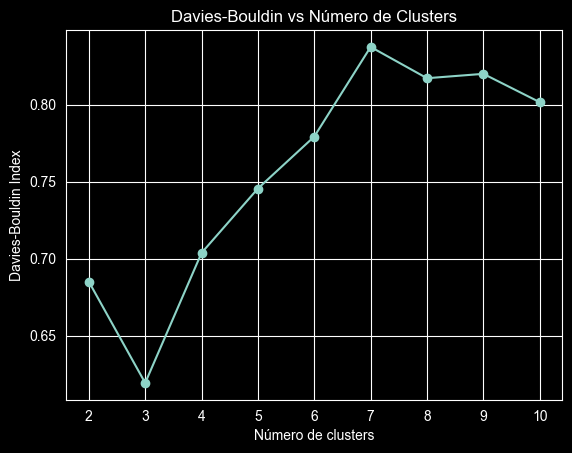

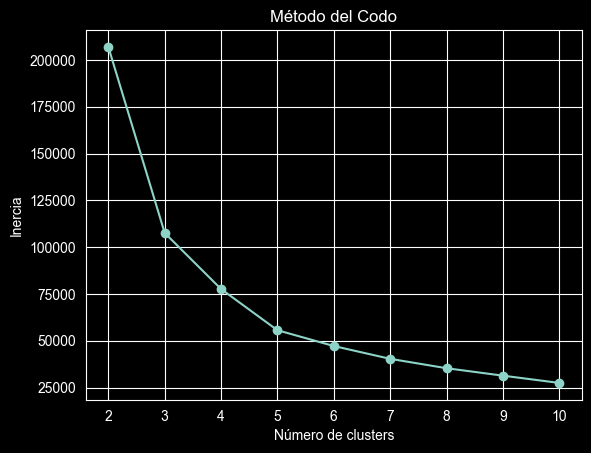

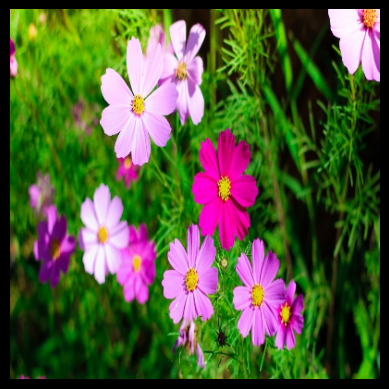

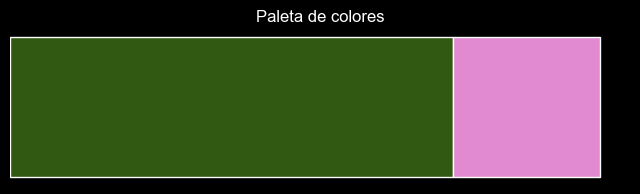

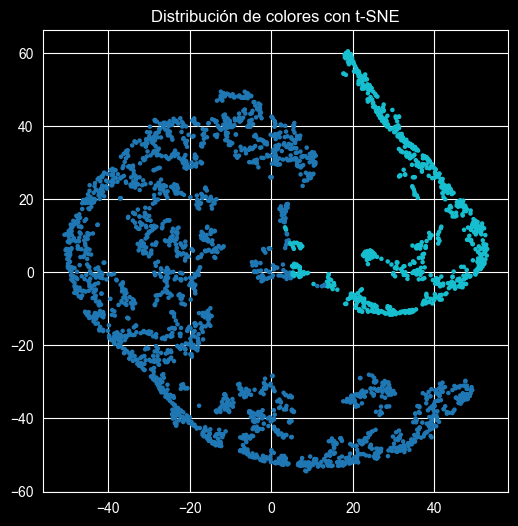

Procesando: image1.jpg


In [ ]:
for i in range(min(5, len(images))):
    print("Procesando:", names[i])
    process_image(images[i])